In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import re
from sklearn.metrics import confusion_matrix
from model import SimpleSpeechCommandModel
import seaborn as sns
from data_loading import create_dataloader, COMMANDS
from transformer import AudioTransformer

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [30]:
def load_model(model_path, num_classes, model_type="cnn", dropout_rate=0, **kwargs):
    if model_type == "cnn":
        model = SimpleSpeechCommandModel(num_classes=num_classes, dropout_rate=dropout_rate)
    elif model_type == "transformer":
        model = AudioTransformer(n_classes=num_classes, dropout=dropout_rate,  **kwargs)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()
    return model

In [18]:
from sklearn.metrics import balanced_accuracy_score


def evaluate_model(model, test_loader, device):
    """ Evaluates the model on a given test dataset and computes accuracy, precision, recall, and F1-score."""
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100
    balanced_accuracy = balanced_accuracy_score(all_labels, all_preds) * 100

    precision = precision_score(all_labels, all_preds, average='macro', zero_division=1) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=1) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=1) * 100

    return {
        "accuracy": accuracy,
        "balanced_accuracy": balanced_accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

In [32]:
def evaluate_models(model_paths, test_loader, device, model_name, model_type="cnn", **kwargs):
    """
    Evaluates multiple models and computes mean and standard deviation for accuracy, precision, recall, and F1-score.
    """
    metrics = {"accuracy": [], "balanced_accuracy": [], "precision": [], "recall": [], "f1_score": []}


    for model_path in model_paths:
        print(f"Evaluating {model_path} ({model_name})...")
        model = load_model(model_path, num_classes=12, model_type=model_type, **kwargs)
        results = evaluate_model(model, test_loader, device)

        for key in metrics.keys():
            metrics[key].append(results[key])

        print(f"Accuracy: {results['accuracy']:.2f}%, Balanced Accuracy: {results['balanced_accuracy']:.2f}%, Precision: {results['precision']:.2f}%, Recall: {results['recall']:.2f}%, F1: {results['f1_score']:.2f}%")

    final_results = {metric: (np.mean(values), np.std(values, ddof=1)) for metric, values in metrics.items()}

    return final_results

In [7]:
def load_loss_data(pattern):
    """Function for loading loss"""
    csv_files = glob.glob(pattern)
    all_data = []

    for file in csv_files:
        match = re.search(r"seed_(\d+)", file)
        seed = int(match.group(1))
        df = pd.read_csv(file, names=["train_loss", "valid_loss"], header=0)
        df["epoch"] = df.index
        df["seed"] = seed
        all_data.append(df)

    df_all = pd.concat(all_data)

    df_grouped = df_all.groupby("epoch").agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        valid_loss_mean=("valid_loss", "mean"),
        valid_loss_std=("valid_loss", "std")
    ).reset_index()

    return df_grouped

In [8]:
def plot_loss(df, model_name, train_color, valid_color, plot_train=True, plot_valid=True):
    """
    Function for plotting loss values.

    Parameters:
    - df: DataFrame containing loss values
    - model_name: Model name printed on legend (e.g., 'Random Flipping')
    - lr: Learning rate value
    - train_color: Color for train loss
    - valid_color: Color for validation loss
    - plot_train: Whether to plot train loss (default: True)
    - plot_valid: Whether to plot validation loss (default: True)
"""
    if plot_train:
        train_label = f"Train Loss: {model_name}"
        plt.plot(df["epoch"], df["train_loss_mean"], label=train_label, color=train_color)
        plt.fill_between(df["epoch"],
                         df["train_loss_mean"] - df["train_loss_std"],
                         df["train_loss_mean"] + df["train_loss_std"],
                         color=train_color, alpha=0.2)

    if plot_valid:
        valid_label = f"Valid Loss: {model_name}"
        plt.plot(df["epoch"], df["valid_loss_mean"], label=valid_label, color=valid_color)
        plt.fill_between(df["epoch"],
                         df["valid_loss_mean"] - df["valid_loss_std"],
                         df["valid_loss_mean"] + df["valid_loss_std"],
                         color=valid_color, alpha=0.2)

In [9]:
def generate_confusion_matrix(model_type, model_path, test_loader, save_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = load_model(model_type, model_path)
    model = model.to(device)
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_loader.dataset.classes, yticklabels=test_loader.dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

    if save_path:
        if save_path.endswith('.csv'):
            cm_df = pd.DataFrame(cm, index=test_loader.dataset.classes, columns=test_loader.dataset.classes)
            cm_df.to_csv(save_path, index=True)
        elif save_path.endswith('.txt'):
            np.savetxt(save_path, cm, fmt='%d', delimiter='\t')
        elif save_path.endswith('.png') or save_path.endswith('.jpg'):
            plt.savefig(save_path, dpi=300)
        else:
            print("Unsupported file extension. Supported extensions: .csv, .txt, .png, .jpg.")
            return

    plt.show()

In [10]:
data_dir = "data/train"
test_loader = create_dataloader(data_dir, batch_size=32, mode='testing')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Learning rate

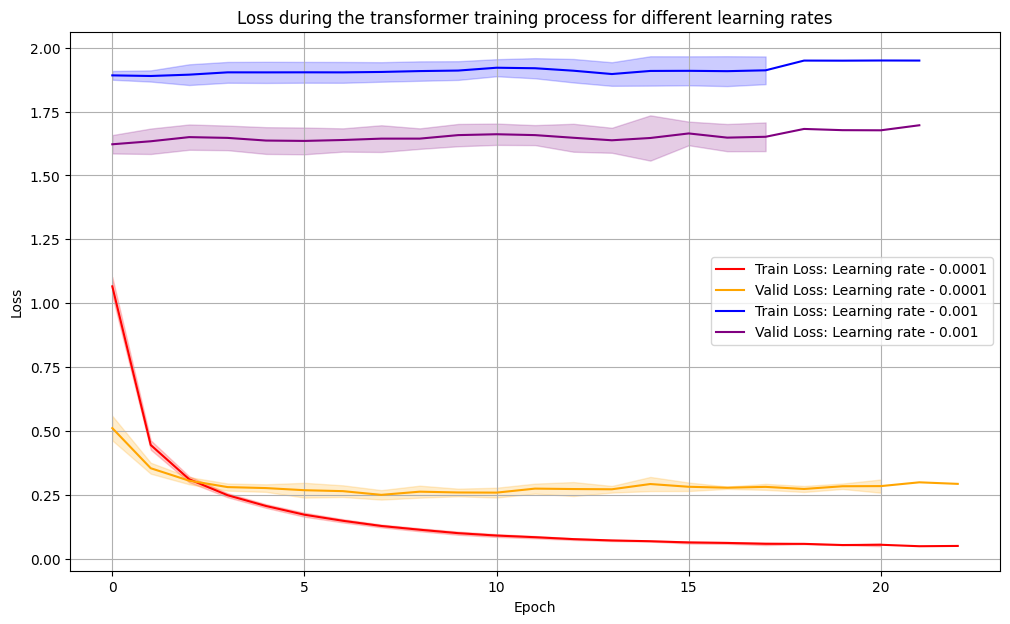

In [15]:
df_cnn_lr001 = load_loss_data("saved_losses/transformer_constant_lr_0.001_seed_*.csv")
df_cnn_lr0001 = load_loss_data("saved_losses/transformer_constant_lr_0.0001_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_cnn_lr0001, "Learning rate - 0.0001", train_color="red", valid_color="orange", plot_valid=True)
plot_loss(df_cnn_lr001, "Learning rate - 0.001", train_color="blue", valid_color="purple", plot_valid=True)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during the transformer training process for different learning rates")
plt.legend()
plt.grid()
plt.savefig("plots/transformer_lr_train")
plt.show()

In [22]:
model_paths = {
    'Constant lr - 0.0001': glob.glob("saved_models/transformer_constant_lr_0.0001_seed_*.pth"),
    'Constant lr - 0.001': glob.glob("saved_models/transformer_constant_lr_0.001_seed_*.pth"),
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths, test_loader, device, model_name, model_type="transformer")

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\transformer_constant_lr_0.0001_seed_1.pth (Constant lr - 0.0001)...
Accuracy: 93.30%, Balanced Accuracy: 89.90%, Precision: 90.12%, Recall: 89.90%, F1: 89.68%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_10.pth (Constant lr - 0.0001)...
Accuracy: 93.69%, Balanced Accuracy: 91.37%, Precision: 90.07%, Recall: 91.37%, F1: 90.60%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_2.pth (Constant lr - 0.0001)...
Accuracy: 93.32%, Balanced Accuracy: 90.72%, Precision: 89.64%, Recall: 90.72%, F1: 90.04%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_3.pth (Constant lr - 0.0001)...
Accuracy: 93.09%, Balanced Accuracy: 88.96%, Precision: 90.89%, Recall: 88.96%, F1: 89.70%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_4.pth (Constant lr - 0.0001)...
Accuracy: 93.39%, Balanced Accuracy: 91.00%, Precision: 89.83%, Recall: 91.00%, F1: 90.27%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_5.pth (Constant lr - 0.0

# Dropout

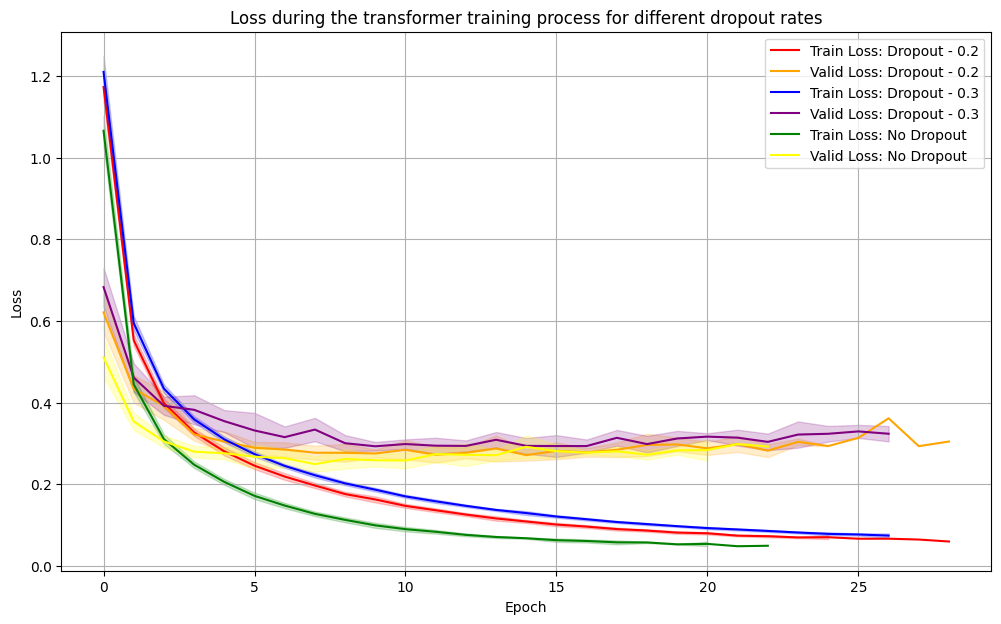

In [24]:
df_transformer_d02 = load_loss_data("saved_losses/transformer_dropout_0.2_seed_*.csv")
df_transformer_d03 = load_loss_data("saved_losses/transformer_dropout_0.3_seed_*.csv")
df_transformer_d0 = load_loss_data("saved_losses/transformer_constant_lr_0.0001_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_transformer_d02, "Dropout - 0.2", train_color="red", valid_color="orange", plot_valid=True)
plot_loss(df_transformer_d03, "Dropout - 0.3", train_color="blue", valid_color="purple", plot_valid=True)
plot_loss(df_transformer_d0, "No Dropout", train_color="green", valid_color="yellow", plot_valid=True)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during the transformer training process for different dropout rates")
plt.legend()
plt.grid()
plt.savefig("plots/transformer_drop_train")
plt.show()

In [25]:
model_paths = {
    'Dropout - 0.2': glob.glob("saved_models/transformer_dropout_0.2_seed_*.pth"),
    'Dropout - 0.3': glob.glob("saved_models/transformer_dropout_0.3_seed_*.pth"),
    'No Dropout': glob.glob("saved_models/transformer_constant_lr_0.0001_seed_*.pth"),
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths, test_loader, device, model_name, model_type="transformer")

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\transformer_dropout_0.2_seed_1.pth (Dropout - 0.2)...
Accuracy: 93.38%, Balanced Accuracy: 88.78%, Precision: 91.63%, Recall: 88.78%, F1: 89.93%
Evaluating saved_models\transformer_dropout_0.2_seed_10.pth (Dropout - 0.2)...
Accuracy: 93.02%, Balanced Accuracy: 90.16%, Precision: 89.54%, Recall: 90.16%, F1: 89.72%
Evaluating saved_models\transformer_dropout_0.2_seed_2.pth (Dropout - 0.2)...
Accuracy: 93.45%, Balanced Accuracy: 91.37%, Precision: 89.46%, Recall: 91.37%, F1: 90.28%
Evaluating saved_models\transformer_dropout_0.2_seed_3.pth (Dropout - 0.2)...
Accuracy: 93.69%, Balanced Accuracy: 88.40%, Precision: 92.84%, Recall: 88.40%, F1: 90.47%
Evaluating saved_models\transformer_dropout_0.2_seed_4.pth (Dropout - 0.2)...
Accuracy: 93.05%, Balanced Accuracy: 90.57%, Precision: 89.50%, Recall: 90.57%, F1: 89.88%
Evaluating saved_models\transformer_dropout_0.2_seed_5.pth (Dropout - 0.2)...
Accuracy: 92.98%, Balanced Accuracy: 90.52%, Precision: 89.19%, Recall: 90.5

# Weight decay

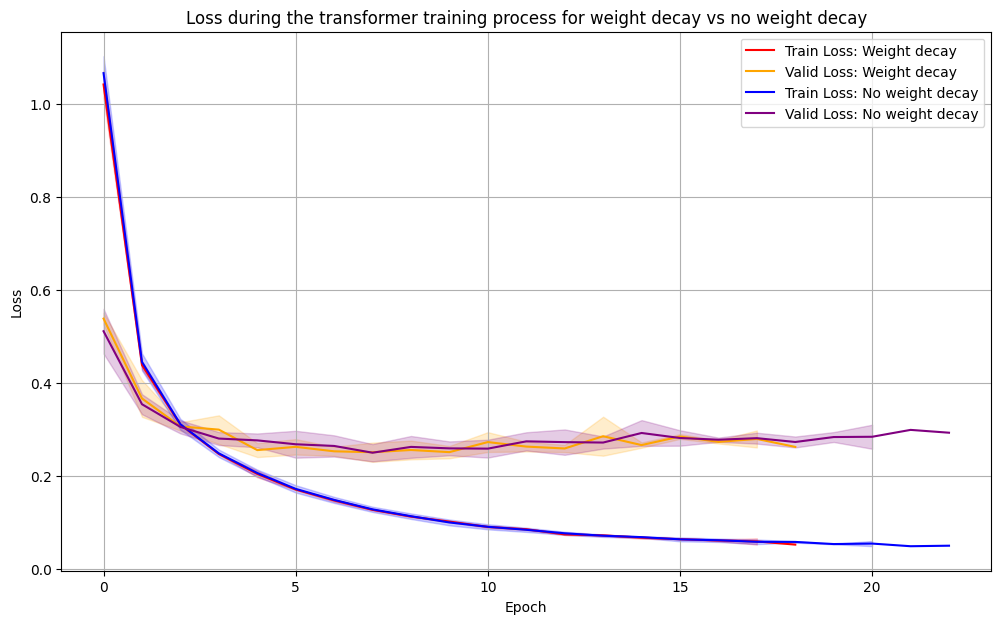

In [26]:
df_transformer_weight_decay = load_loss_data("saved_losses/transformer_weight_decay_0.01_seed_*.csv")
df_transformer_no_weight = load_loss_data("saved_losses/transformer_constant_lr_0.0001_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_transformer_weight_decay, "Weight decay", train_color="red", valid_color="orange", plot_valid=True)
plot_loss(df_transformer_no_weight, "No weight decay", train_color="blue", valid_color="purple", plot_valid=True)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during the transformer training process for weight decay vs no weight decay")
plt.legend()
plt.grid()
plt.savefig("plots/transformer_weight_decay_train")
plt.show()

In [27]:
model_paths = {
    'Weight decay': glob.glob("saved_models/transformer_weight_decay_0.01_seed_*.pth"),
    'No weight decay': glob.glob("saved_models/transformer_constant_lr_0.0001_seed_*.pth"),
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths, test_loader, device, model_name, model_type="transformer")

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\transformer_weight_decay_0.01_seed_1.pth (Weight decay)...
Accuracy: 93.84%, Balanced Accuracy: 89.43%, Precision: 91.63%, Recall: 89.43%, F1: 90.40%
Evaluating saved_models\transformer_weight_decay_0.01_seed_2.pth (Weight decay)...
Accuracy: 93.23%, Balanced Accuracy: 89.19%, Precision: 90.76%, Recall: 89.19%, F1: 89.71%
Evaluating saved_models\transformer_weight_decay_0.01_seed_3.pth (Weight decay)...
Accuracy: 93.97%, Balanced Accuracy: 91.99%, Precision: 90.35%, Recall: 91.99%, F1: 91.09%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_1.pth (No weight decay)...
Accuracy: 93.30%, Balanced Accuracy: 89.90%, Precision: 90.12%, Recall: 89.90%, F1: 89.68%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_10.pth (No weight decay)...
Accuracy: 93.69%, Balanced Accuracy: 91.37%, Precision: 90.07%, Recall: 91.37%, F1: 90.60%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_2.pth (No weight decay)...
Accuracy: 93.32%, Balanced Accurac

# Model Dimension

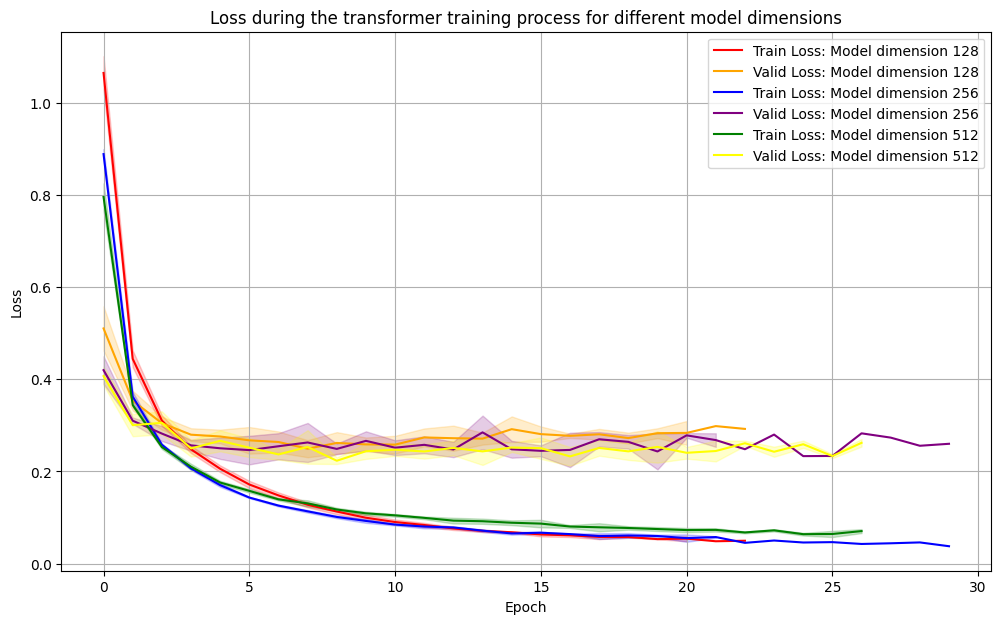

In [28]:
df_transformer_128 = load_loss_data("saved_losses/transformer_constant_lr_0.0001_seed_*.csv")
df_transformer_256 = load_loss_data("saved_losses/transformer_experiment_256_4_4_0_seed_*.csv")
df_transformer_512 = load_loss_data("saved_losses/transformer_experiment_512_4_4_0_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_transformer_128, "Model dimension 128", train_color="red", valid_color="orange", plot_valid=True)
plot_loss(df_transformer_256, "Model dimension 256", train_color="blue", valid_color="purple", plot_valid=True)
plot_loss(df_transformer_512, "Model dimension 512", train_color="green", valid_color="yellow", plot_valid=True)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during the transformer training process for different model dimensions")
plt.legend()
plt.grid()
plt.savefig("plots/transformer_model_dim_train")
plt.show()

In [33]:
model_paths = {
    'Model dimension 128': [glob.glob("saved_models/transformer_constant_lr_0.0001_seed_*.pth"), 128],
    'Model dimension 256': [glob.glob("saved_models/transformer_experiment_256_4_4_0_seed_*.pth"), 256],
    'Model dimension 512': [glob.glob("saved_models/transformer_experiment_512_4_4_0_seed_*.pth"), 512],
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths[0], test_loader, device, model_name, model_type="transformer", d_model=paths[1])

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\transformer_constant_lr_0.0001_seed_1.pth (Model dimension 128)...
Accuracy: 93.30%, Balanced Accuracy: 89.90%, Precision: 90.12%, Recall: 89.90%, F1: 89.68%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_10.pth (Model dimension 128)...
Accuracy: 93.67%, Balanced Accuracy: 91.34%, Precision: 90.05%, Recall: 91.34%, F1: 90.58%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_2.pth (Model dimension 128)...
Accuracy: 93.32%, Balanced Accuracy: 90.72%, Precision: 89.64%, Recall: 90.72%, F1: 90.04%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_3.pth (Model dimension 128)...
Accuracy: 93.09%, Balanced Accuracy: 88.96%, Precision: 90.89%, Recall: 88.96%, F1: 89.70%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_4.pth (Model dimension 128)...
Accuracy: 93.39%, Balanced Accuracy: 91.00%, Precision: 89.83%, Recall: 91.00%, F1: 90.27%
Evaluating saved_models\transformer_constant_lr_0.0001_seed_5.pth (Model dimension 128)..

# Number of layers

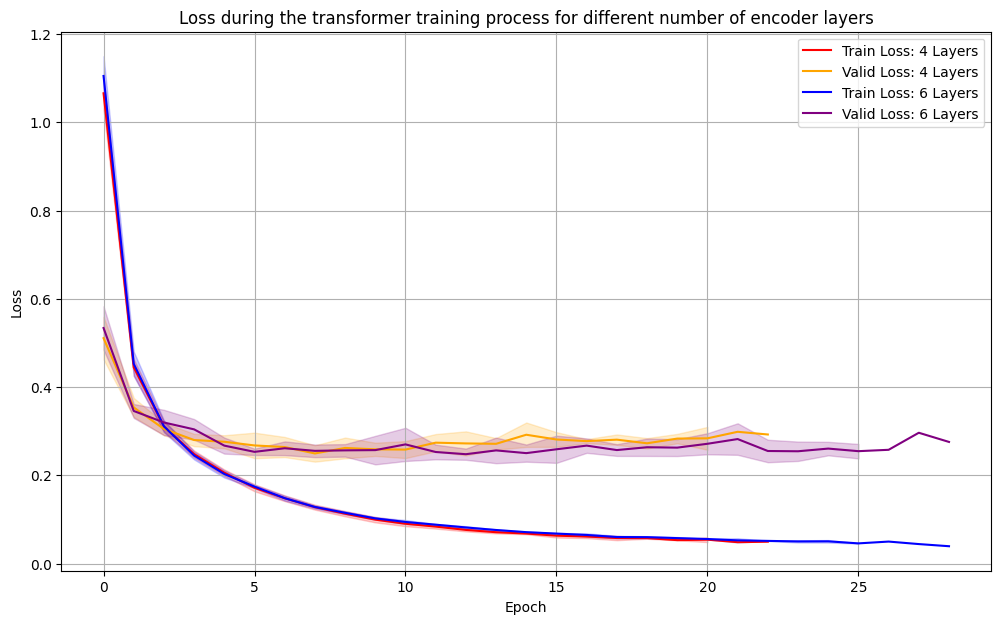

In [35]:
df_transformer_4 = load_loss_data("saved_losses/transformer_constant_lr_0.0001_seed_*.csv")
df_transformer_6 = load_loss_data("saved_losses/transformer_experiment_128_4_6_0_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_transformer_4, "4 Layers", train_color="red", valid_color="orange", plot_valid=True)
plot_loss(df_transformer_6, "6 Layers", train_color="blue", valid_color="purple", plot_valid=True)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss during the transformer training process for different number of encoder layers")
plt.legend()
plt.grid()
plt.savefig("plots/transformer_model_layer_train")
plt.show()

In [ ]:
model_paths = {
    'Layers 4': [glob.glob("saved_models/transformer_constant_lr_0.0001_seed_*.pth"), 4],
    'Layers 6': [glob.glob("saved_models/transformer_experiment_128_4_6_0_seed_*.pth"), 6],
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths[0], test_loader, device, model_name, model_type="transformer", d_model=paths[1])

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")